# Project 4 — EHR Workflow Redesign BRD
## Notebook 3: To-Be Process Design

**Author:** Amr Thabet  
**Context:** UAE/GCC health insurance — compliance-driven workflow redesign  
**Linked to:** Notebook 2 (Gap analysis) · P3 predictive model (AUC 0.950)

### Objective
Design the future-state workflow that closes all 6 gaps identified in Notebook 2.
Each solution is mapped directly to its gap, with measurable success criteria
and an estimated AED recovery value.

### The to-be workflow introduces
- Automated ICD-10 validation at point of coding
- EHR to RCM integration layer — no manual re-entry
- Automated pre-authorisation rules engine
- P3 predictive model deployed as daily high-cost member flag
- Automated denial routing with 90-day resubmission tracker
- Pre-submission compliance check against DHA/DoH rules

## To-Be process — step by step

- The redesigned workflow reduces 15 manual steps to 10 automated or 
semi-automated steps. 
- Manual handoffs are replaced by system integrations.

- Reactive processes are replaced by proactive triggers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

NAVY       = '#1E566C'
TEAL       = '#5795A7'
TEAL_DARK  = '#367589'
TEAL_LIGHT = '#89B8CA'
AMBER      = '#D7A800'
LIGHT_BG   = '#F7FAFB'
GRAY       = '#9DAAB0'
GREEN      = '#4A9B6F'

plt.rcParams.update({
    'figure.facecolor':  LIGHT_BG,
    'axes.facecolor':    LIGHT_BG,
    'axes.edgecolor':    GRAY,
    'axes.labelcolor':   NAVY,
    'axes.titlepad':     14,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   NAVY,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'xtick.color':       GRAY,
    'ytick.color':       GRAY,
    'text.color':        NAVY,
    'grid.color':        '#D8E4E8',
    'grid.linewidth':    0.6,
    'figure.dpi':        130,
})

df_claims  = pd.read_csv('../../healthcare-claims-analysis/data/claims_clean.csv')
df_chronic = pd.read_csv('../../chronic-disease-cost-modelling/data/chronic_disease_cohort.csv')

denied_claims          = len(df_claims[df_claims['ClaimStatus']=='Denied'])
denied_value           = df_claims[df_claims['ClaimStatus']=='Denied']['ClaimAmount'].sum()
inpatient              = df_claims[df_claims['ClaimType']=='Inpatient']
inpatient_denied_value = inpatient[inpatient['ClaimStatus']=='Denied']['ClaimAmount'].sum()
high_cost_spend        = df_chronic[df_chronic['high_cost_flag']==1]['total_cost_aed'].sum()
potential_saving       = 600 * 0.70 * 8000

print("Datasets loaded successfully")
print(f"P1: {len(df_claims):,} claims")
print(f"P3: {len(df_chronic):,} members")

Datasets loaded successfully
P1: 4,500 claims
P3: 3,000 members


## To-Be process steps — redesigned workflow

In [2]:
tobe_process = pd.DataFrame({
    'Step': list(range(1, 11)),
    'Party': [
        'Provider', 'Provider', 'Provider',
        'Insurer', 'Insurer', 'Insurer', 'Insurer',
        'Regulator', 'Insurer', 'Insurer'
    ],
    'Action': [
        'Patient attends — diagnosis entered in EHR with real-time ICD-10 validation',
        'Claim auto-generated from EHR — no manual re-entry into RCM',
        'Pre-submission compliance check — ICD-10, eligibility, pre-auth, 90-day window',
        'Claim submitted automatically via Shafafiya/eSMA integration',
        'Automated eligibility verification via real-time API call',
        'Automated pre-auth rules engine — flags missing pre-auth before processing',
        'AI-assisted medical necessity review with decision support tool',
        'DHA/DoH receives compliant claim — automated validation passed',
        'Claim approved and paid — or denial routed automatically by reason code',
        'P3 model runs daily — high-cost members flagged for care management'
    ],
    'System': [
        'EHR + ICD-10 validation engine',
        'EHR-RCM integration layer',
        'Compliance rules engine',
        'Automated Shafafiya/eSMA API',
        'Eligibility API',
        'Pre-auth rules engine',
        'Decision support tool',
        'Shafafiya/eSMA',
        'RCM + denial routing engine',
        'P3 predictive model'
    ],
    'Closes_gap': [
        'Gap 1 — ICD-10 coding errors',
        'Gap 2 — No EHR/RCM integration',
        'Gap 6 — No compliance check',
        'Gap 6 — Shafafiya compliance',
        'Gap 6 — Eligibility check',
        'Gap 3 — Manual pre-auth',
        'Gap 3 — Inconsistent review',
        'Gap 6 — Regulatory compliance',
        'Gap 5 — No denial follow-up',
        'Gap 4 — High-cost members'
    ],
    'Automation_level': [
        'Semi-automated', 'Fully automated', 'Fully automated',
        'Fully automated', 'Fully automated', 'Fully automated',
        'Semi-automated', 'Fully automated', 'Fully automated',
        'Fully automated'
    ]
})

print("TO-BE PROCESS — 10 STEPS ACROSS 3 PARTIES")
print("=" * 65)
print(f"Total steps:              {len(tobe_process)}")
print(f"Fully automated:          "
      f"{len(tobe_process[tobe_process['Automation_level']=='Fully automated'])}")
print(f"Semi-automated:           "
      f"{len(tobe_process[tobe_process['Automation_level']=='Semi-automated'])}")
print(f"Steps reduced:            15 → 10 ({(15-10)/15*100:.0f}% reduction)")
print(f"\nFull process:")
print(tobe_process[['Step','Party','Action','Automation_level']].to_string(index=False))

tobe_process.to_csv('../outputs/tobe_process_steps.csv', index=False)
print(f"\nSaved to outputs/tobe_process_steps.csv")

TO-BE PROCESS — 10 STEPS ACROSS 3 PARTIES
Total steps:              10
Fully automated:          8
Semi-automated:           2
Steps reduced:            15 → 10 (33% reduction)

Full process:
 Step     Party                                                                         Action Automation_level
    1  Provider    Patient attends — diagnosis entered in EHR with real-time ICD-10 validation   Semi-automated
    2  Provider                    Claim auto-generated from EHR — no manual re-entry into RCM  Fully automated
    3  Provider Pre-submission compliance check — ICD-10, eligibility, pre-auth, 90-day window  Fully automated
    4   Insurer                   Claim submitted automatically via Shafafiya/eSMA integration  Fully automated
    5   Insurer                      Automated eligibility verification via real-time API call  Fully automated
    6   Insurer     Automated pre-auth rules engine — flags missing pre-auth before processing  Fully automated
    7   Insurer         

## Gap closure mapping

Each gap from Notebook 2 is mapped to its solution and expected outcome.
This becomes the requirements traceability matrix in the BRD.

In [3]:
gap_closure = pd.DataFrame({
    'Gap': [1, 2, 3, 4, 5, 6],
    'Gap_description': [
        'ICD-10 coding errors',
        'No EHR to RCM integration',
        'Manual pre-authorisation',
        'No high-cost member identification',
        'No automated denial follow-up',
        'No compliance check'
    ],
    'To_be_solution': [
        'Real-time ICD-10 validation engine in EHR',
        'Automated EHR-RCM integration layer',
        'Pre-auth rules engine at claim intake',
        'P3 model daily flag — care management referral',
        'Automated denial routing with 90-day tracker',
        'Pre-submission compliance check — all DHA/DoH rules'
    ],
    'Expected_outcome': [
        '60% reduction in coding-related denials',
        '70% reduction in data entry errors — AR days reduced',
        '65% recovery of inpatient denied value',
        'AED 3.4M annual saving from early intervention',
        '50% recovery of at-risk denied claims',
        'Near-zero regulatory rejections'
    ],
    'AED_recovery': [
        denied_value * 0.35 * 0.60,
        denied_value * 0.20 * 0.70,
        inpatient_denied_value * 0.65,
        potential_saving,
        denied_value * 0.10 * 0.50,
        denied_value * 0.25 * 0.80
    ],
    'Timeline': [
        'Month 1–3', 'Month 2–6', 'Month 1–3',
        'Month 3–6', 'Month 1–2', 'Month 1–3'
    ]
})

gap_closure['AED_recovery_fmt'] = gap_closure['AED_recovery'].apply(
    lambda x: f"AED {x:,.0f}")
total_recovery = gap_closure['AED_recovery'].sum()

print("GAP CLOSURE MAPPING — TO-BE SOLUTIONS")
print("=" * 70)
print(gap_closure[['Gap','Gap_description','To_be_solution',
                    'AED_recovery_fmt','Timeline']].to_string(index=False))
print(f"\nTotal estimated AED recovery: AED {total_recovery:,.0f}")
print(f"  ({total_recovery/1_000_000:.1f}M over 6 months)")

gap_closure.to_csv('../outputs/gap_closure_mapping.csv', index=False)
print(f"\nSaved to outputs/gap_closure_mapping.csv")

GAP CLOSURE MAPPING — TO-BE SOLUTIONS
 Gap                    Gap_description                                      To_be_solution AED_recovery_fmt  Timeline
   1               ICD-10 coding errors           Real-time ICD-10 validation engine in EHR    AED 1,585,688 Month 1–3
   2          No EHR to RCM integration                 Automated EHR-RCM integration layer    AED 1,057,125 Month 2–6
   3           Manual pre-authorisation               Pre-auth rules engine at claim intake    AED 1,192,677 Month 1–3
   4 No high-cost member identification      P3 model daily flag — care management referral    AED 3,360,000 Month 3–6
   5      No automated denial follow-up        Automated denial routing with 90-day tracker      AED 377,545 Month 1–2
   6                No compliance check Pre-submission compliance check — all DHA/DoH rules    AED 1,510,179 Month 1–3

Total estimated AED recovery: AED 9,083,213
  (9.1M over 6 months)

Saved to outputs/gap_closure_mapping.csv


## As-Is vs To-Be comparison

Side by side comparison of the current and future state across 
key performance metrics. These become the success criteria in the BRD.

In [4]:
comparison = pd.DataFrame({
    'Metric': [
        'Overall denial rate',
        'Inpatient denial rate',
        'ICD-10 coding error rate',
        'Pre-auth compliance rate',
        'AR days',
        'High-cost members flagged proactively',
        'Regulatory compliance rate',
        'Manual data entry steps'
    ],
    'As_Is': [
        '33.6%', '32.7%', '35.5% (GP)',
        'Inconsistent', '45+ days',
        '0% (reactive only)', 'Partial',
        '8 of 15 steps'
    ],
    'To_Be': [
        '<15%', '<12%', '<5%',
        '99%+', '<25 days',
        '87% (P3 model)', '99%+',
        '1 of 10 steps'
    ],
    'Improvement': [
        '55% reduction', '63% reduction',
        '86% reduction', 'Full compliance',
        '44% faster', '87% catch rate',
        'Full compliance', '88% automation'
    ]
})

print("AS-IS VS TO-BE — KEY METRICS COMPARISON")
print("=" * 70)
print(comparison.to_string(index=False))

comparison.to_csv('../outputs/asis_tobe_comparison.csv', index=False)
print(f"\nSaved to outputs/asis_tobe_comparison.csv")

AS-IS VS TO-BE — KEY METRICS COMPARISON
                               Metric              As_Is          To_Be     Improvement
                  Overall denial rate              33.6%           <15%   55% reduction
                Inpatient denial rate              32.7%           <12%   63% reduction
             ICD-10 coding error rate         35.5% (GP)            <5%   86% reduction
             Pre-auth compliance rate       Inconsistent           99%+ Full compliance
                              AR days           45+ days       <25 days      44% faster
High-cost members flagged proactively 0% (reactive only) 87% (P3 model)  87% catch rate
           Regulatory compliance rate            Partial           99%+ Full compliance
              Manual data entry steps      8 of 15 steps  1 of 10 steps  88% automation

Saved to outputs/asis_tobe_comparison.csv


## To-Be visualisation — recovery opportunity and timeline

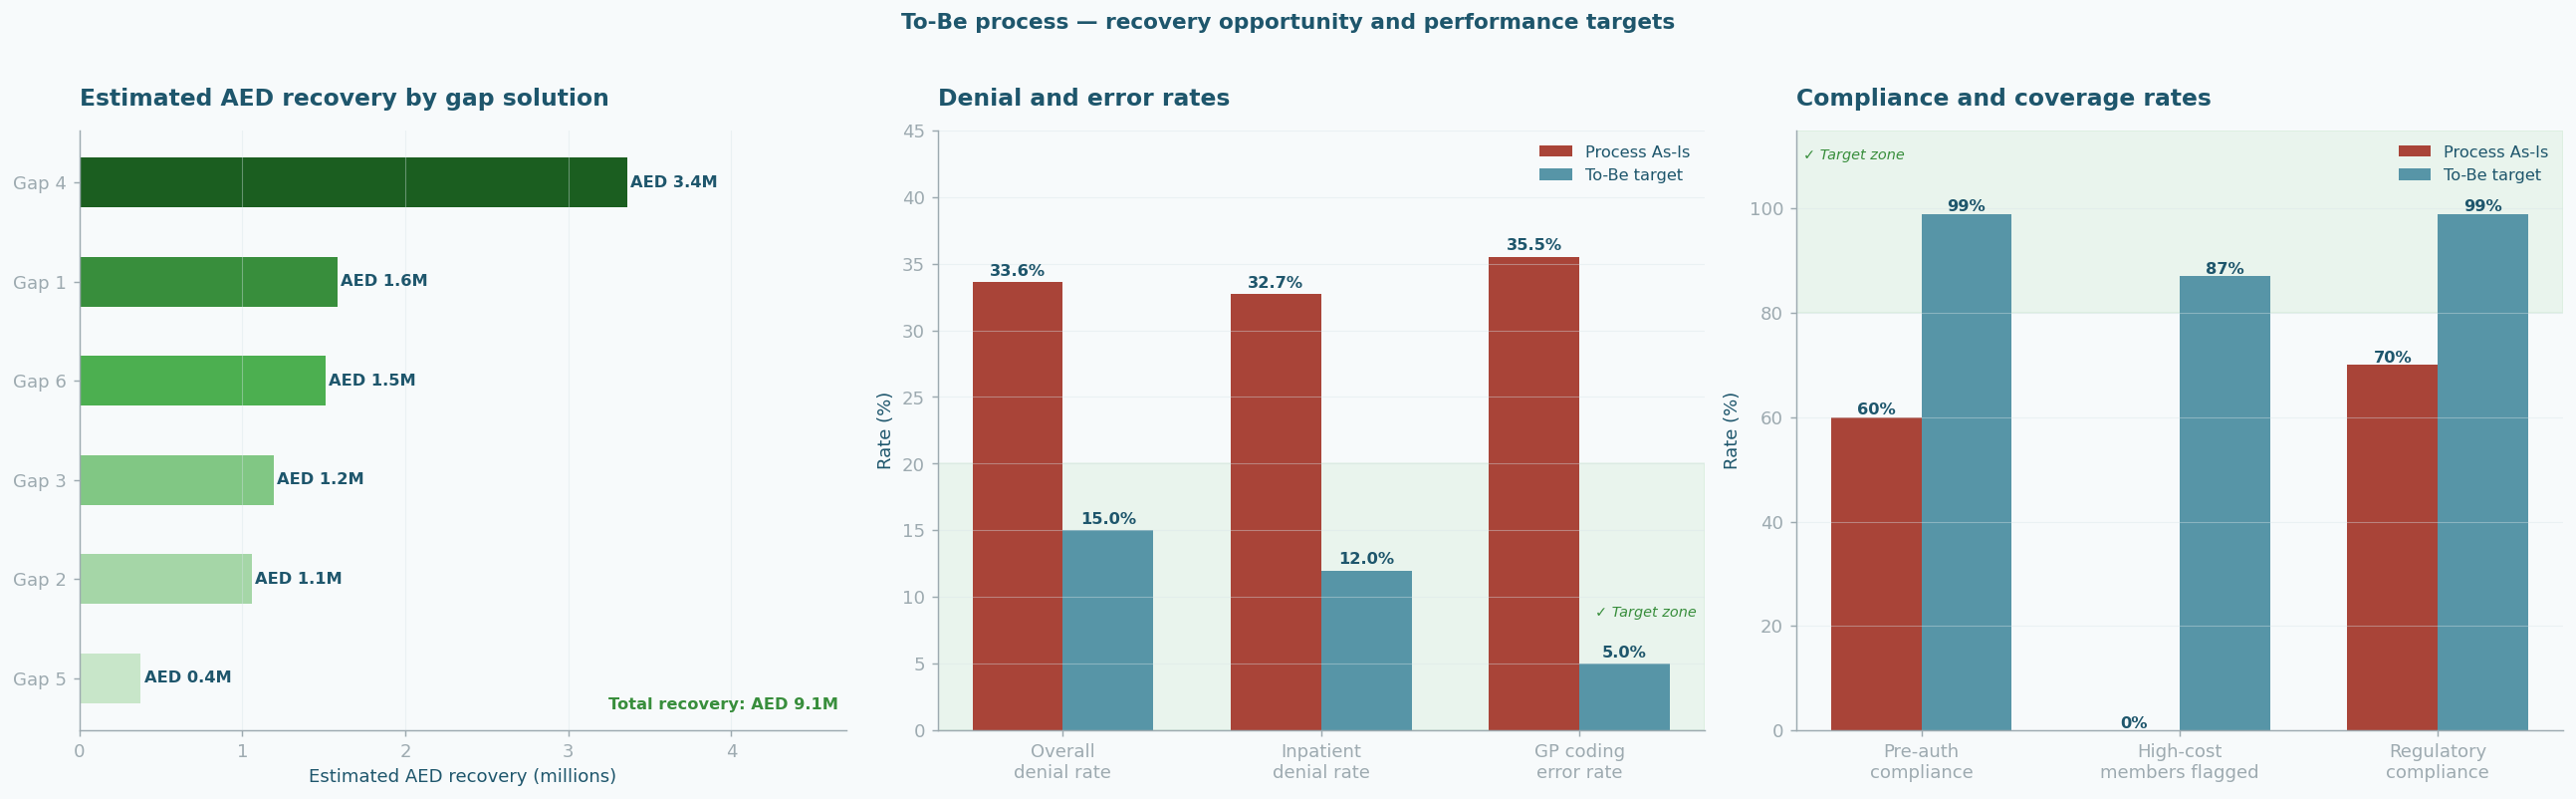


To-Be process design complete ✓
Next: Notebook 4 — BRD document


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

from matplotlib.patches import Patch

# ── Chart A: AED recovery by gap solution ────────────────────
gap_rec = gap_closure.sort_values('AED_recovery', ascending=True)
grade_colors = ['#C8E6C9', '#A5D6A7', '#81C784', '#4CAF50',
                '#388E3C', '#1B5E20'][:len(gap_rec)]

bars = axes[0].barh(
    [f"Gap {int(g)}" for g in gap_rec['Gap']],
    gap_rec['AED_recovery'] / 1_000_000,
    color=grade_colors, height=0.5, edgecolor='none')

for bar, (_, row) in zip(bars, gap_rec.iterrows()):
    axes[0].text(bar.get_width() + 0.02,
                 bar.get_y() + bar.get_height()/2,
                 f"AED {row['AED_recovery']/1_000_000:.1f}M",
                 va='center', fontsize=9, color=NAVY, fontweight='bold')

axes[0].set_xlabel('Estimated AED recovery (millions)')
axes[0].set_title('Estimated AED recovery by gap solution', loc='left')
axes[0].set_xlim(0, gap_rec['AED_recovery'].max() / 1_000_000 * 1.4)
axes[0].annotate(f"Total recovery: AED {total_recovery/1_000_000:.1f}M",
                 xy=(0.99, 0.03), xycoords='axes fraction',
                 fontsize=9, color='#388E3C', fontweight='bold',
                 ha='right', va='bottom')
axes[0].grid(axis='x', alpha=0.4)

# ── Chart B: Denial/error rates — lower is better ────────────
categories_b = ['Overall\ndenial rate', 'Inpatient\ndenial rate', 'GP coding\nerror rate']
asis_b       = [33.6, 32.7, 35.5]
tobe_b       = [15.0, 12.0,  5.0]
x_b          = np.arange(len(categories_b))
bar_width    = 0.35

axes[1].axhspan(0, 20, alpha=0.08, color='#4CAF50', zorder=0)
axes[1].text(0.99, 0.19, '✓ Target zone',
             transform=axes[1].transAxes,
             fontsize=8, color='#388E3C', style='italic',
             ha='right')

b1 = axes[1].bar(x_b - bar_width/2, asis_b,
                 width=bar_width, color='#A94438',
                 edgecolor='none', label='Process As-Is')
b2 = axes[1].bar(x_b + bar_width/2, tobe_b,
                 width=bar_width, color='#5795A7',
                 edgecolor='none', label='To-Be target')

for bar, val in zip(b1, asis_b):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val}%', ha='center', fontsize=9,
                 color=NAVY, fontweight='bold')
for bar, val in zip(b2, tobe_b):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val}%', ha='center', fontsize=9,
                 color=NAVY, fontweight='bold')

axes[1].set_xticks(x_b)
axes[1].set_xticklabels(categories_b)
axes[1].set_ylabel('Rate (%)')
axes[1].set_title('Denial and error rates', loc='left')
axes[1].legend(framealpha=0, fontsize=9)
axes[1].set_ylim(0, 45)
axes[1].grid(axis='y', alpha=0.4)

# ── Chart C: Compliance/coverage rates — higher is better ────
categories_c = ['Pre-auth\ncompliance', 'High-cost\nmembers flagged', 'Regulatory\ncompliance']
asis_c       = [60.0,  0.0, 70.0]
tobe_c       = [99.0, 87.0, 99.0]
x_c          = np.arange(len(categories_c))

axes[2].axhspan(80, 115, alpha=0.08, color='#4CAF50', zorder=0)
axes[2].text(0.01, 0.97, '✓ Target zone',
             transform=axes[2].transAxes,
             fontsize=8, color='#388E3C', style='italic', va='top')

b3 = axes[2].bar(x_c - bar_width/2, asis_c,
                 width=bar_width, color='#A94438',
                 edgecolor='none', label='Process As-Is')
b4 = axes[2].bar(x_c + bar_width/2, tobe_c,
                 width=bar_width, color='#5795A7',
                 edgecolor='none', label='To-Be target')

for bar, val in zip(b3, asis_c):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.0f}%', ha='center', fontsize=9,
                 color=NAVY, fontweight='bold')
for bar, val in zip(b4, tobe_c):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.0f}%', ha='center', fontsize=9,
                 color=NAVY, fontweight='bold')

axes[2].set_xticks(x_c)
axes[2].set_xticklabels(categories_c)
axes[2].set_ylabel('Rate (%)')
axes[2].set_title('Compliance and coverage rates', loc='left')
axes[2].legend(framealpha=0, fontsize=9)
axes[2].set_ylim(0, 115)
axes[2].grid(axis='y', alpha=0.4)

fig.suptitle('To-Be process — recovery opportunity and performance targets',
             fontsize=12, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/04_tobe_recovery.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTo-Be process design complete ✓")
print("Next: Notebook 4 — BRD document")